In [2]:
from pathlib import Path
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white")

df = pd.read_csv("../data/raw/student-mat.csv", sep=";")

In [3]:
print(df.shape)

print(df.columns)

display(df.head())

(395, 33)
Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [4]:
df.columns = df.columns.str.strip()

In [5]:
if "G3" not in df.columns:
    raise KeyError("G3 not found.")

In [6]:
for col in ["G1","G2","G3"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [7]:
print(df[["G1","G2","G3"]].isna().sum())

G1    0
G2    0
G3    0
dtype: int64


In [8]:
numeric_df = df.select_dtypes(include="number")

In [9]:
corr = numeric_df.corr(method="pearson")

In [10]:
display(corr.round(3))

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
age,1.000,-0.164,-0.163,0.071,-0.004,0.244,0.054,0.016,0.127,0.131,0.117,-0.062,0.175,-0.064,-0.143,-0.162
Medu,-0.164,1.000,0.623,-0.172,0.065,-0.237,-0.004,0.031,0.064,0.020,-0.047,-0.047,0.100,0.205,0.216,0.217
Fedu,-0.163,0.623,1.000,-0.158,-0.009,-0.250,-0.001,-0.013,0.043,0.002,-0.013,0.015,0.024,0.190,0.165,0.152
traveltime,0.071,-0.172,-0.158,1.000,-0.101,0.092,-0.017,-0.017,0.029,0.138,0.134,0.008,-0.013,-0.093,-0.153,-0.117
studytime,-0.004,0.065,-0.009,-0.101,1.000,-0.174,0.040,-0.143,-0.064,-0.196,-0.254,-0.076,-0.063,0.161,0.136,0.098
failures,0.244,-0.237,-0.250,0.092,-0.174,1.000,-0.044,0.092,0.125,0.136,0.142,0.066,0.064,-0.355,-0.356,-0.360
famrel,0.054,-0.004,-0.001,-0.017,0.040,-0.044,1.000,0.151,0.065,-0.078,-0.113,0.094,-0.044,0.022,-0.018,0.051
freetime,0.016,0.031,-0.013,-0.017,-0.143,0.092,0.151,1.000,0.285,0.209,0.148,0.076,-0.058,0.013,-0.014,0.011
goout,0.127,0.064,0.043,0.029,-0.064,0.125,0.065,0.285,1.000,0.267,0.420,-0.010,0.044,-0.149,-0.162,-0.133
Dalc,0.131,0.020,0.002,0.138,-0.196,0.136,-0.078,0.209,0.267,1.000,0.648,0.077,0.112,-0.094,-0.064,-0.055


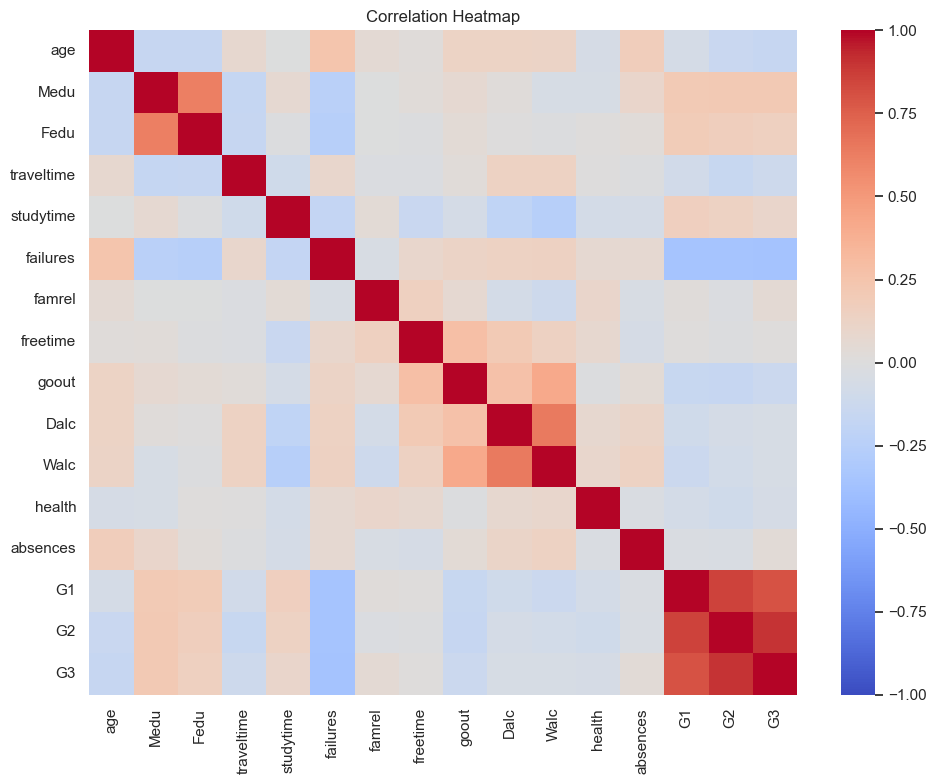

In [11]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    annot=False,
    vmin=-1,
    vmax=1
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.savefig("../figures/correlation_heatmap.png", dpi=300)

plt.show()

In [12]:
g3_corr = (
    corr["G3"]
    .drop("G3")
    .sort_values(ascending=False)
)

print(g3_corr.head(8))

G2           0.904868
G1           0.801468
Medu         0.217147
Fedu         0.152457
studytime    0.097820
famrel       0.051363
absences     0.034247
freetime     0.011307
Name: G3, dtype: float64


In [13]:
strongest = (
    corr["G3"]
    .drop("G3")
    .sort_values(
        key=lambda x: x.abs(),
        ascending=False
    )
)

print(strongest.head(10))

G2            0.904868
G1            0.801468
failures     -0.360415
Medu          0.217147
age          -0.161579
Fedu          0.152457
goout        -0.132791
traveltime   -0.117142
studytime     0.097820
health       -0.061335
Name: G3, dtype: float64


In [14]:
grade_corr = df[["G1","G2","G3"]].corr()

display(grade_corr)

,G1,G2,G3
G1,1.000000,0.852118,0.801468
G2,0.852118,1.000000,0.904868
G3,0.801468,0.904868,1.000000


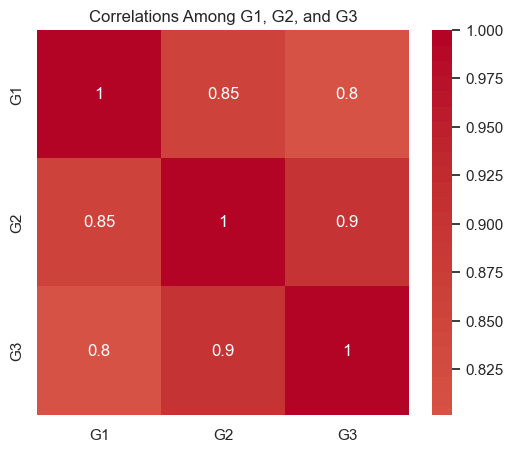

In [15]:
plt.figure(figsize=(6,5))

sns.heatmap(
    grade_corr,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Correlations Among G1, G2, and G3")

plt.show()

In [16]:
grade_correlations = df[["G1", "G2", "G3"]].corr()
print(f"G1-G3 correlation: {grade_correlations.loc['G1', 'G3']:.3f}")
print(f"G2-G3 correlation: {grade_correlations.loc['G2', 'G3']:.3f}")

G1-G3 correlation: 0.801
G2-G3 correlation: 0.905
